<a href="https://colab.research.google.com/github/manon306/-/blob/main/dm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [70]:
df_original = pd.read_csv("./netflix_titles.csv", on_bad_lines='skip')
df = df_original.copy()

In [71]:
print(df.shape)

(8807, 12)


In [72]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [73]:
for i in df.columns:
    null = df[i].isnull().sum()/df.shape[0]*100
    if null > 0:
        print(f"{i} null value :{round(null,2)}")

director null value :29.91
cast null value :9.37
country null value :9.44
date_added null value :0.11
rating null value :0.05
duration null value :0.03


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [75]:
df1 = df.copy()

In [76]:
df1.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [77]:
print("\nDublicate Values : ")
print(df1.duplicated().sum())


Dublicate Values : 
0


In [78]:
df1['show_id'] = df1['show_id'].str.replace('s','').astype(int)

In [79]:
# its a actual movies name not random number
df[df['title'].str.isnumeric()]['title']

,title
858,678
1113,2012
2443,122
2798,3022
3808,1994
4350,1983
5207,1922
5388,46
5958,9
5959,21


In [80]:
# fetch all rows contain : in title and save into tem
tem = df1[df1['title'].str.contains(":")]

In [81]:
#rows title that contain director name at start
drictor_name_strt = tem[tem['title'].str.split(":").str.get(0) == tem['director']]
new_title = drictor_name_strt['title'].str.split(":").str.get(1)
df1.loc[new_title.index,'title'] = new_title.values

In [82]:
#rows title that contain actor name at start
actor_name_strt = tem[tem['title'].str.split(":").str.get(0) == tem['cast']]
new_title = actor_name_strt['title'].str.split(":").str.get(1)
df1.loc[new_title.index,'title'] = new_title.values

In [83]:
#remove leading and trailing spaces
df1['date_added'] = df1['date_added'].str.strip()

In [84]:
df1['date_added'] = pd.to_datetime(df1['date_added'], format='%d-%b-%y', errors='coerce')


In [85]:
df1['director'] = df1['director'].str.split(",").str.get(0)

In [86]:
df1['cast'] = df1['cast'].str.split(",")

In [87]:
def extract_actor(lst):
    """"This fuction extract lead  actor name form cast column
    """
    if (type(lst) == list) and (len(lst) > 0):
        return lst[0]
    else:
        return np.nan

def extract_actress(lst):
    """"This fuction extract lead  actress name form cast column
    """
    if (type(lst) == list) and (len(lst) > 1):
        return lst[1]
    else:
        return np.nan

In [88]:
df1['lead_actor'] = df1['cast'].apply(extract_actor)
df1['lead_actress'] = df1['cast'].apply(extract_actress)

In [89]:
df1['country'] =df1['country'].str.split(",").str.get(0)

In [90]:
df1.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,lead_actor,lead_actress
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN,NaN
1,2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Ama Qamata,Khosi Ngema


In [91]:
def clean_genere(lst):
    """
    This function clean gnere column
    """
    new_list = []
    remove_words = ['tv','international','shows','movies','&','']
    if (type(lst) == list ) and (len(lst) > 0):
        for i in lst:
            for j in i.split(" "):
                if j.lower() not in remove_words:
                    new_list.append(j.lower())
                else:
                    pass
        return new_list
    else:
        return np.nan

In [92]:
df1['listed_in'] = df1['listed_in'].str.split(",").apply(clean_genere)

In [93]:
df1.rename(columns={'listed_in':'genere'},inplace=True)

In [94]:
df1.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genere,description,lead_actor,lead_actress
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[documentaries],"As her father nears the end of his life, filmm...",NaN,NaN
1,2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[dramas, mysteries]","After crossing paths at a party, a Cape Town t...",Ama Qamata,Khosi Ngema


In [95]:
df1['type'] = df1['type'].astype('category')
df1['rating'] = df1['rating'].astype('category')

In [96]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   int64         
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   category      
 9   duration      8804 non-null   object        
 10  genere        8807 non-null   object        
 11  description   8807 non-null   object        
 12  lead_actor    7982 non-null   object        
 13  lead_actress  7101 non-null   object        
dtypes: category(2), datetime64[ns](1), int64(2), object(9)
memory usage: 843.8+ KB


In [97]:
print("\nNull Values : ")
print(df.isnull().sum())


Null Values : 
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [98]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


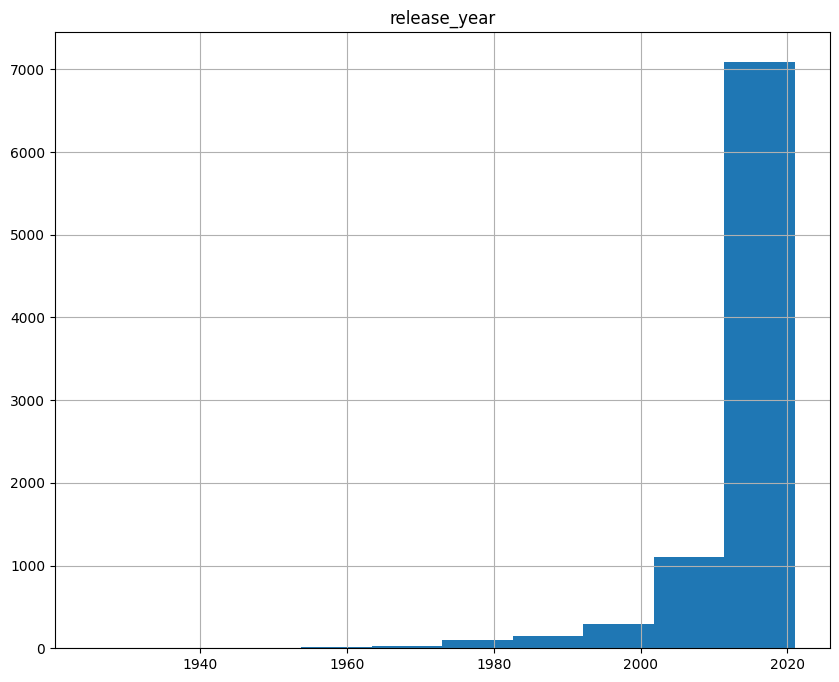

In [99]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.hist(figsize=(10,8))
plt.show()

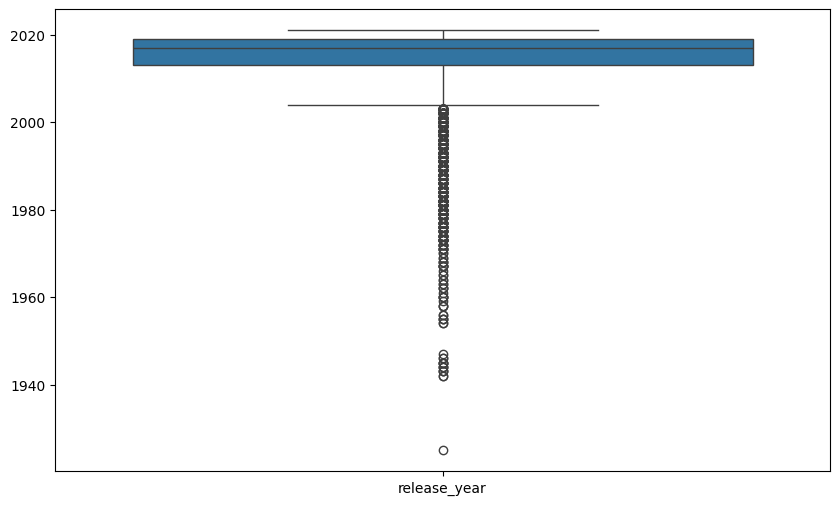

In [100]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_numeric)
plt.show()

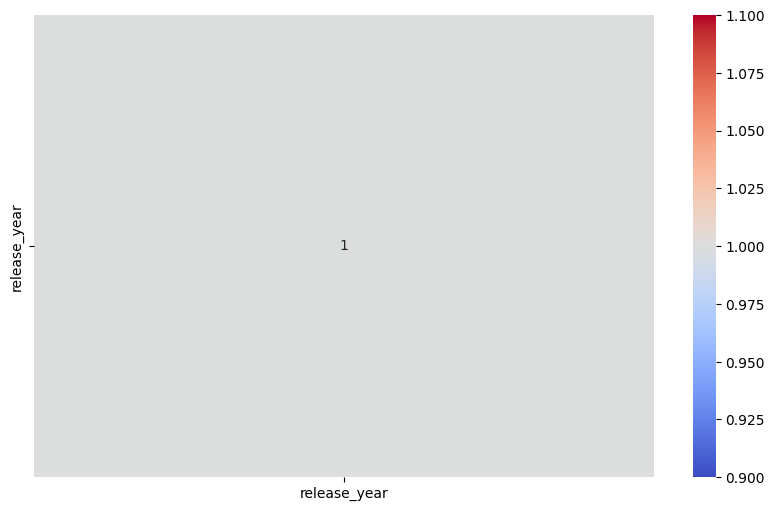

In [101]:
plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

In [102]:
# Fill string missing values with "Unknown"
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

# Fill missing country with Mode
df["country"] = df["country"].fillna(df["country"].mode()[0])

# Convert date_added safely
df["date_added"] = pd.to_datetime(df["date_added"], errors='coerce', format='mixed')

# Fill missing after conversion
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

# Fill rating and duration
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])


In [103]:
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

outliers = df[(df['release_year'] < lower_bound) | (df['release_year'] > upper_bound)]
print("Outliers Count:", len(outliers))

# Cap outliers
df['release_year'] = np.where(df['release_year'] > upper_bound,
                            upper_bound,
                            np.where(df['release_year'] < lower_bound,
                                    lower_bound,
                                    df['release_year']))



Lower: 2004.0
Upper: 2028.0
Outliers Count: 719


In [104]:
scaler = MinMaxScaler()

df1['release_year_scaled'] = scaler.fit_transform(df[['release_year']])
df1['duration_num_scaled'] = scaler.fit_transform(df[['date_added']])


In [105]:
top_countries = df['country'].value_counts().nlargest(10).index
df1["country"] = df["country"].apply(lambda x: x if x in top_countries else "Other")


In [106]:
df1["listed_in"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip())
top_genres = df["listed_in"].value_counts().nlargest(20).index
df1["listed_in"] = df["listed_in"].apply(
    lambda x: x if x in top_genres else "Other"
)

In [107]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   show_id              8807 non-null   int64         
 1   type                 8807 non-null   category      
 2   title                8807 non-null   object        
 3   director             6173 non-null   object        
 4   cast                 7982 non-null   object        
 5   country              8807 non-null   object        
 6   date_added           8709 non-null   datetime64[ns]
 7   release_year         8807 non-null   int64         
 8   rating               8803 non-null   category      
 9   duration             8804 non-null   object        
 10  genere               8807 non-null   object        
 11  description          8807 non-null   object        
 12  lead_actor           7982 non-null   object        
 13  lead_actress         7101 non-nul

In [108]:
# Drop columns you don't want first
df1 = df1.drop(["show_id", "title", "director", "cast", "description", "duration"], axis=1)

categorical_columns = ["type", "rating", "date_added", "listed_in", "country"]

# Then create dummy variables
df_encoded = pd.get_dummies(df1, columns=categorical_columns, drop_first=True)

print(df_encoded.head())
print(df_encoded.shape)


   release_year                      genere     lead_actor     lead_actress  \
0          2020             [documentaries]            NaN              NaN   
1          2021         [dramas, mysteries]     Ama Qamata      Khosi Ngema   
2          2021  [crime, action, adventure]  Sami Bouajila     Tracy Gotoas   
3          2021       [docuseries, reality]            NaN              NaN   
4          2021        [romantic, comedies]     Mayur More   Jitendra Kumar   

   release_year_scaled  duration_num_scaled  type_TV Show  rating_74 min  \
0             0.941176             1.000000         False          False   
1             1.000000             0.999801          True          False   
2             1.000000             0.999801          True          False   
3             1.000000             0.999801          True          False   
4             1.000000             0.999801          True          False   

   rating_84 min  rating_G  ...  country_Egypt  country_France  coun

In [109]:
df_encoded = df_encoded.drop([
    "show_id", "title", "director", "cast",
    "description", "date_added", "duration"
], axis=1, errors='ignore')  # <- ignore missing columns


In [110]:
df_encoded.to_csv("cleaned_DM_data_2.csv", index=False)

df_encoded["type_Movie"] = ~df_encoded["type_TV Show"]


df_encoded.info
df_encoded.describe
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Columns: 1752 entries, release_year to type_Movie
dtypes: bool(1746), float64(2), int64(1), object(3)
memory usage: 15.1+ MB


In [111]:
print("The missing values is handeled ? :")
print(df.isnull().sum())

print("The Outliers is handeled ? :")
print(df[(df['release_year'] < lower_bound) | (df['release_year'] > upper_bound)])

print("The Encoding  is handeled ? :")
print(df_encoded.head())
print(df_encoded.select_dtypes(include=['object']).columns)

print("Check Dataset Shape")
print(df_encoded.shape)

print("Check Scaling")
print(df['release_year_scaled'].min(), df['release_year_scaled'].max())

print ("Check for Wrong Values After Encoding")
print(df.dtypes)

The missing values is handeled ? :
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
The Outliers is handeled ? :
Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Index: []
The Encoding  is handeled ? :
   release_year                      genere     lead_actor     lead_actress  \
0          2020             [documentaries]            NaN              NaN   
1          2021         [dramas, mysteries]     Ama Qamata      Khosi Ngema   
2          2021  [crime, action, adventure]  Sami Bouajila     Tracy Gotoas   
3          2021       [docuseries, reality]            NaN              NaN   
4          2021        [romantic, comedies]     Mayur More   Jitendra Kumar   

   release_year_scaled  duration_num_scaled  type_T

KeyError: 'release_year_scaled'